In [68]:
import pandas as pd

df = pd.read_csv("/content/student_placement_prediction_final_1000.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 12)


In [69]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,522,8.33,1,3,5,89,4.3,Yes,Yes,75,91,Placed
1,738,6.49,1,2,2,77,2.8,No,Yes,72,78,Placed
2,741,7.82,1,3,2,65,3.8,Yes,Yes,87,84,Placed
3,661,7.34,2,1,2,86,2.7,Yes,Yes,95,79,NotPlaced
4,412,7.95,0,2,5,80,3.9,Yes,Yes,82,98,Placed


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  1000 non-null   int64  
 1   CGPA                       1000 non-null   float64
 2   Internships                1000 non-null   int64  
 3   Projects                   1000 non-null   int64  
 4   Workshops/Certifications   1000 non-null   int64  
 5   AptitudeTestScore          1000 non-null   int64  
 6   SoftSkillsRating           1000 non-null   float64
 7   ExtracurricularActivities  1000 non-null   object 
 8   PlacementTraining          1000 non-null   object 
 9   SSC_Marks                  1000 non-null   int64  
 10  HSC_Marks                  1000 non-null   int64  
 11  PlacementStatus            1000 non-null   object 
dtypes: float64(2), int64(7), object(3)
memory usage: 93.9+ KB


In [71]:
df["PlacementStatus"].value_counts()

,count
PlacementStatus,
Placed,554
NotPlaced,446


In [72]:
df_ml = df.drop("StudentID", axis=1).copy()

print(df_ml.columns.tolist())

['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']


In [73]:
df_ml["ExtracurricularActivities"] = df_ml["ExtracurricularActivities"].map({
    "Yes": 1,
    "No": 0
})

df_ml["PlacementTraining"] = df_ml["PlacementTraining"].map({
    "Yes": 1,
    "No": 0
})

df_ml["PlacementStatus"] = df_ml["PlacementStatus"].map({
    "Placed": 1,
    "NotPlaced": 0
})

print(df_ml.head())

   CGPA  Internships  Projects  Workshops/Certifications  AptitudeTestScore  \
0  8.33            1         3                         5                 89   
1  6.49            1         2                         2                 77   
2  7.82            1         3                         2                 65   
3  7.34            2         1                         2                 86   
4  7.95            0         2                         5                 80   

   SoftSkillsRating  ExtracurricularActivities  PlacementTraining  SSC_Marks  \
0               4.3                          1                  1         75   
1               2.8                          0                  1         72   
2               3.8                          1                  1         87   
3               2.7                          1                  1         95   
4               3.9                          1                  1         82   

   HSC_Marks  PlacementStatus  
0         91

In [74]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CGPA                       1000 non-null   float64
 1   Internships                1000 non-null   int64  
 2   Projects                   1000 non-null   int64  
 3   Workshops/Certifications   1000 non-null   int64  
 4   AptitudeTestScore          1000 non-null   int64  
 5   SoftSkillsRating           1000 non-null   float64
 6   ExtracurricularActivities  1000 non-null   int64  
 7   PlacementTraining          1000 non-null   int64  
 8   SSC_Marks                  1000 non-null   int64  
 9   HSC_Marks                  1000 non-null   int64  
 10  PlacementStatus            1000 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 86.1 KB


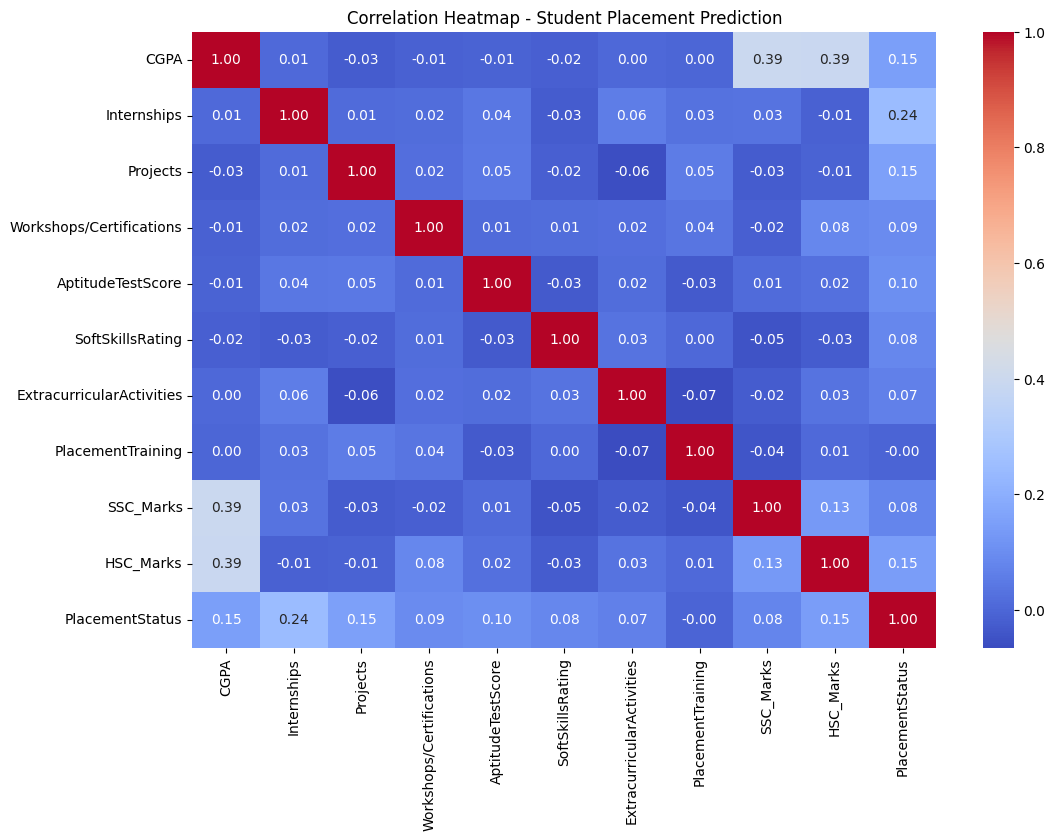

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df_ml.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Student Placement Prediction")
plt.show()

In [76]:
X = df_ml.drop("PlacementStatus", axis=1)
y = df_ml["PlacementStatus"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
       'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities',
       'PlacementTraining', 'SSC_Marks', 'HSC_Marks'],
      dtype='object')

Target:
PlacementStatus


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 10)
Testing data: (200, 10)


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [79]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression predictions completed!")

Logistic Regression predictions completed!


In [80]:
from sklearn.metrics import accuracy_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)
print("Accuracy Percentage:", round(accuracy_logistic * 100, 2), "%")

Logistic Regression Accuracy: 0.69
Accuracy Percentage: 69.0 %


In [81]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Not Placed", "Placed"]
))

              precision    recall  f1-score   support

  Not Placed       0.68      0.57      0.62        89
      Placed       0.70      0.78      0.74       111

    accuracy                           0.69       200
   macro avg       0.69      0.68      0.68       200
weighted avg       0.69      0.69      0.69       200



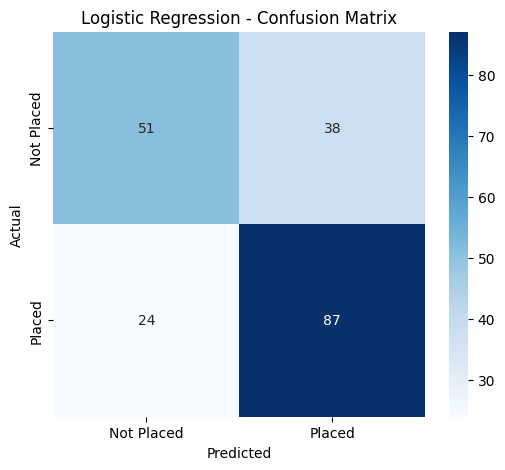

In [82]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [83]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

decision_tree.fit(X_train, y_train)

y_pred_tree = decision_tree.predict(X_test)

print("Decision Tree predictions completed!")

Decision Tree predictions completed!


In [85]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.625

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.66      0.61        89
           1       0.69      0.59      0.64       111

    accuracy                           0.62       200
   macro avg       0.63      0.63      0.62       200
weighted avg       0.63      0.62      0.63       200



In [86]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [87]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.73

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.58      0.66        89
           1       0.72      0.85      0.78       111

    accuracy                           0.73       200
   macro avg       0.74      0.72      0.72       200
weighted avg       0.73      0.73      0.72       200



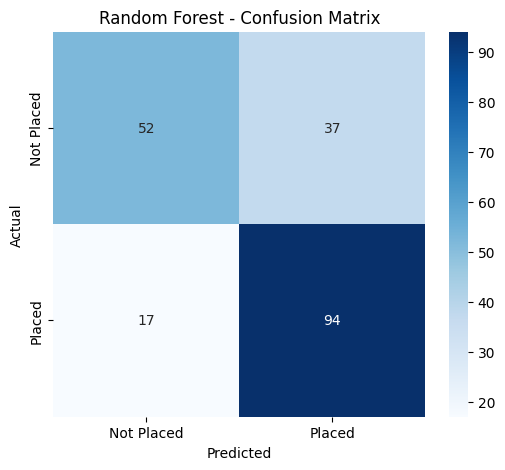

In [88]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.show()

Feature Importance:
CGPA                         0.172797
AptitudeTestScore            0.147768
Internships                  0.146497
HSC_Marks                    0.131797
SoftSkillsRating             0.130293
SSC_Marks                    0.093033
Projects                     0.087443
Workshops/Certifications     0.060237
ExtracurricularActivities    0.018357
PlacementTraining            0.011777
dtype: float64


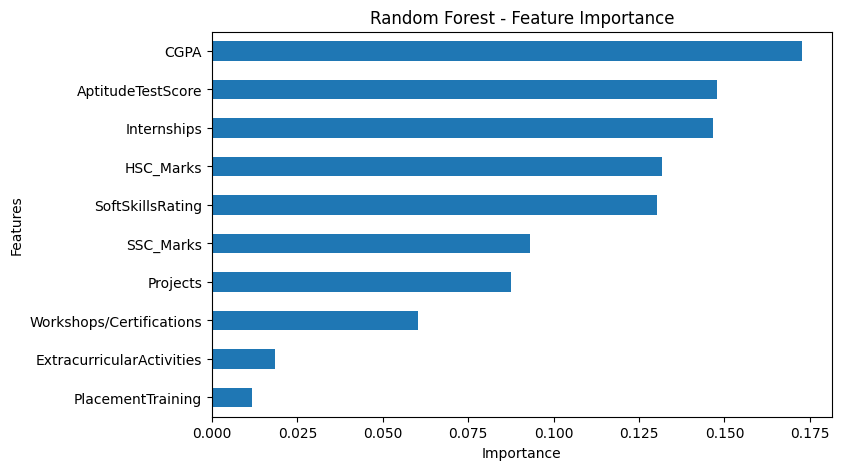

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest - Feature Importance")

plt.show()

In [90]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation Scores: [0.545 0.635 0.665 0.645 0.665]
Mean CV Accuracy: 0.631
Standard Deviation: 0.04454211490264017


In [91]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-Validation Scores: [0.64  0.62  0.64  0.61  0.645]
Mean CV Accuracy: 0.631
Standard Deviation: 0.013564659966250548


In [93]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.6439999999999999


In [94]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)

print("Final Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_final))

Final Random Forest Accuracy: 0.72


Final Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.57      0.65        89
           1       0.71      0.84      0.77       111

    accuracy                           0.72       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.72      0.71       200



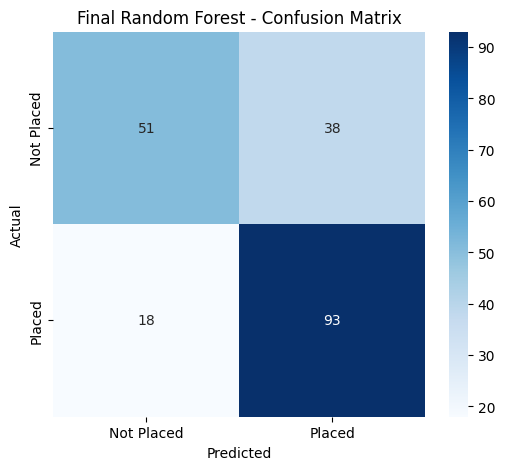

In [95]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Final Random Forest Classification Report:")
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Random Forest - Confusion Matrix")

plt.show()

In [96]:
import joblib

joblib.dump(final_model, "student_placement_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_final)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic, pos_label=1),
        precision_score(y_test, y_pred_tree, pos_label=1),
        precision_score(y_test, y_pred_rf, pos_label=1),
        precision_score(y_test, y_pred_final, pos_label=1)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic, pos_label=1),
        recall_score(y_test, y_pred_tree, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1),
        recall_score(y_test, y_pred_final, pos_label=1)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic, pos_label=1),
        f1_score(y_test, y_pred_tree, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1),
        f1_score(y_test, y_pred_final, pos_label=1)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.690,0.696000,0.783784,0.737288
1,Decision Tree,0.625,0.687500,0.594595,0.637681
2,Random Forest,0.730,0.717557,0.846847,0.776860
3,Tuned Random Forest,0.720,0.709924,0.837838,0.768595


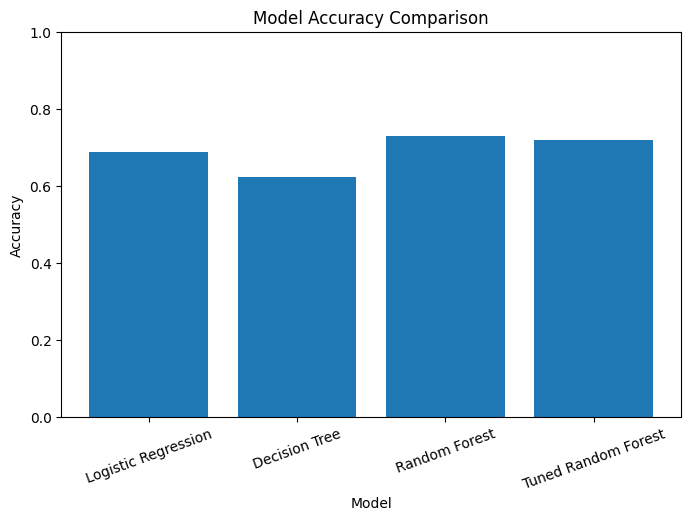

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

In [99]:
print("Final Model: Random Forest Classifier")

print("\nParameters:")
print("Number of Trees:", final_model.n_estimators)
print("Maximum Depth:", final_model.max_depth)
print("Minimum Samples Split:", final_model.min_samples_split)
print("Minimum Samples Leaf:", final_model.min_samples_leaf)

Final Model: Random Forest Classifier

Parameters:
Number of Trees: 200
Maximum Depth: 5
Minimum Samples Split: 2
Minimum Samples Leaf: 1


In [100]:
feature_importance_final = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Final Feature Importance:")
print(feature_importance_final)

Final Feature Importance:
CGPA                         0.170764
AptitudeTestScore            0.148861
Internships                  0.140342
HSC_Marks                    0.130083
SoftSkillsRating             0.127968
SSC_Marks                    0.096842
Projects                     0.088001
Workshops/Certifications     0.065116
ExtracurricularActivities    0.020527
PlacementTraining            0.011496
dtype: float64


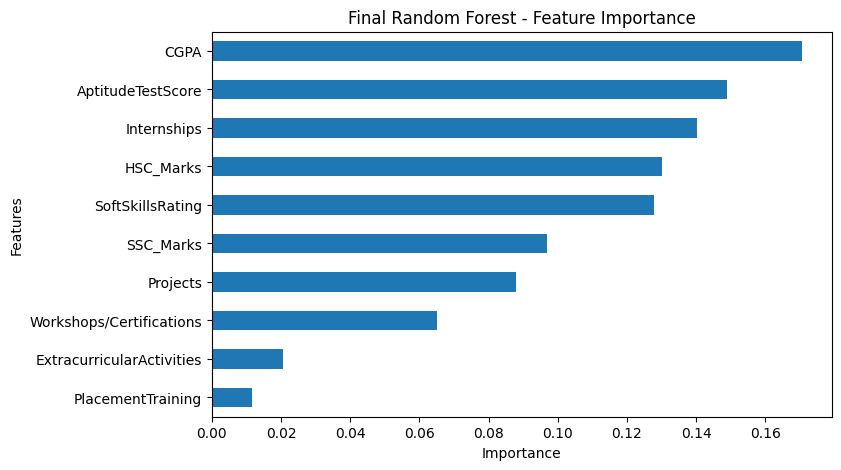

In [101]:
plt.figure(figsize=(8, 5))

feature_importance_final.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Final Random Forest - Feature Importance")

plt.show()

In [102]:
sample_student = pd.DataFrame([{
    "CGPA": 8.2,
    "Internships": 2,
    "Projects": 3,
    "Workshops/Certifications": 4,
    "AptitudeTestScore": 78,
    "SoftSkillsRating": 4,
    "ExtracurricularActivities": 1,
    "PlacementTraining": 1,
    "SSC_Marks": 85,
    "HSC_Marks": 82
}])

prediction = final_model.predict(sample_student)

if prediction[0] == 1:
    print("Prediction: Placed")
else:
    print("Prediction: Not Placed")

Prediction: Placed


In [103]:
probability = final_model.predict_proba(sample_student)[0]

print("Probability of Not Placed:", round(probability[0] * 100, 2), "%")
print("Probability of Placed:", round(probability[1] * 100, 2), "%")

Probability of Not Placed: 28.41 %
Probability of Placed: 71.59 %


In [104]:
import joblib

joblib.dump(final_model, "student_placement_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [105]:
print("=" * 50)
print("STUDENT PLACEMENT PREDICTION - FINAL RESULTS")
print("=" * 50)

print("\nFinal Model: Tuned Random Forest Classifier")
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_final) * 100, 2), "%")
print("Best Cross-Validation Accuracy: 64.4%")

print("\nKey Predictive Features:")
for feature, importance in feature_importance_final.head(5).items():
    print(f"{feature}: {importance:.4f}")

print("\nModel saved as: student_placement_model.pkl")

STUDENT PLACEMENT PREDICTION - FINAL RESULTS

Final Model: Tuned Random Forest Classifier
Test Accuracy: 72.0 %
Best Cross-Validation Accuracy: 64.4%

Key Predictive Features:
CGPA: 0.1708
AptitudeTestScore: 0.1489
Internships: 0.1403
HSC_Marks: 0.1301
SoftSkillsRating: 0.1280

Model saved as: student_placement_model.pkl
